In [140]:
import pandas as pd
import torch
from torch import nn as nn
from torch import optim as optim
from sklearn.preprocessing import MinMaxScaler, MaxAbsScaler
from sklearn.metrics import mean_squared_error
from torch.utils.data import Dataset, DataLoader
import numpy as np
import gc
import optuna
import math
import matplotlib.pyplot as plt

In [141]:
%config InteractiveShell.ast_node_interactivity = 'all'

In [142]:
%config InteractiveShell.ast_node_interactivity = 'last_expr'

In [143]:
data = pd.DataFrame(pd.read_csv("000420.XSHE.csv", parse_dates=["datetime"]).set_index("datetime"))
data = data[["close"]].resample("D").last().dropna()
data.describe()

,close
count,4373.000000
mean,2.719561
std,1.201007
min,0.790000
25%,1.770000
50%,2.560000
75%,3.470000
max,6.780000


In [144]:
print(data.head(30))

            close
datetime         
2005-01-04   1.47
2005-01-05   1.48
2005-01-06   1.47
2005-01-07   1.48
2005-01-10   1.49
2005-01-11   1.48
2005-01-12   1.52
2005-01-13   1.51
2005-01-14   1.48
2005-01-17   1.42
2005-01-18   1.44
2005-01-19   1.43
2005-01-20   1.37
2005-01-21   1.40
2005-01-24   1.43
2005-01-25   1.44
2005-01-26   1.41
2005-01-27   1.39
2005-01-28   1.35
2005-01-31   1.27
2005-02-01   1.27
2005-02-02   1.36
2005-02-03   1.32
2005-02-04   1.38
2005-02-16   1.39
2005-02-17   1.40
2005-02-18   1.37
2005-02-21   1.40
2005-02-22   1.43
2005-02-23   1.43


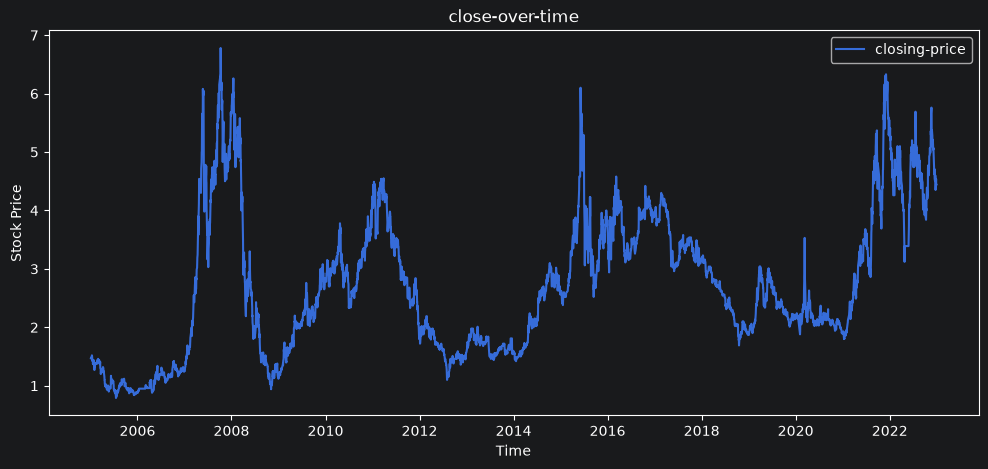

In [145]:
fig=plt.figure()
fig.set_figwidth(12)
fig.set_figheight(5)
plt.plot(data, label='closing-price')
plt.title('close-over-time')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [146]:
data["close_processed"] = data["close"].diff()
data.dropna(subset=["close_processed"], inplace=True)

sc = MaxAbsScaler()
# Changing to GMADL requires a symmetrical scaling function

n = len(data)
look_back = 60
batch_size = 32
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = sc.fit_transform(data[["close_processed"]].iloc[:train_end])
val_data = sc.transform(data[["close_processed"]].iloc[train_end - look_back : val_end])
test_data = sc.transform(data[["close_processed"]].iloc[val_end - look_back :])

class TimeSeriesDataset(Dataset):
    def __init__(self, data_array, look_back=look_back):
        self.data = torch.from_numpy(data_array).float()
        self.look_back = look_back

    def __len__(self):
        return len(self.data) - self.look_back

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.look_back]
        y = self.data[idx + self.look_back]
        return x, y


train_dataset = TimeSeriesDataset(train_data)
val_dataset = TimeSeriesDataset(val_data)
test_dataset = TimeSeriesDataset(test_data)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [147]:
# forgot i needed to plot MSE again oops
sc_mm = MinMaxScaler()
sc_mm.fit(data[["close_processed"]].iloc[:train_end])

val_data_mm = sc_mm.transform(data[["close_processed"]].iloc[train_end - look_back : val_end])
test_data_mm = sc_mm.transform(data[["close_processed"]].iloc[val_end - look_back :])

val_loader_mm = DataLoader(TimeSeriesDataset(val_data_mm), batch_size=batch_size, shuffle=False)
test_loader_mm = DataLoader(TimeSeriesDataset(test_data_mm), batch_size=batch_size, shuffle=False)

In [148]:
class Net(nn.Module):
    def __init__(self, num_layers, hidden_size, input_size=1, output_size=1, dropout=0.2):
        super(Net, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, output_size) #last layer

    def forward(self, x): #forward method
       out, _ = self.gru(x)
       last= out[:, -1, :]
       return self.fc(last)

In [149]:
class GMADL(nn.Module):
    def __init__(self, direction_weight: float =7, magnitude_weight: float= 3, mse_alpha: float=10, eps: float = 1e-8):
        super().__init__()
        self.direction_weight=direction_weight
        self.magnitude_weight=magnitude_weight
        self.eps = eps
        self.mse_alpha=mse_alpha

    def forward(self, input, target):
        direction_term = torch.sigmoid(self.direction_weight*input*target)-0.5
        magnitude_term = torch.pow(torch.abs(target)+self.eps, self.magnitude_weight)
        lossGMADL = -1*magnitude_term*direction_term
        loss_mse = torch.mean((input - target) ** 2)
        # to nie jest oparte na poprawnej funkcji
        return torch.mean(lossGMADL)+(self.mse_alpha * loss_mse)

In [150]:
def objective(trial):
    layer_number = trial.suggest_int("layer_number", 1, 2)
    hidden_size = trial.suggest_int('hidden_size', 16, 128, step = 16)
    learning_rate = trial.suggest_float('lr', 8e-4, 5e-3, log=True)

    # loss function hyperparameters
    direction_weight = trial.suggest_float("direction_weight", 50, 300, log=True)
    magnitude_weight = trial.suggest_float("magnitude_weight", 1, 2)
    mse_weight = trial.suggest_float("mse_alpha", 0.001, 0.03, log=True)

    model = Net(layer_number, hidden_size, input_size=1, output_size=1, dropout=0.2)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    criterion = GMADL(direction_weight,magnitude_weight)

    for epoch in range(5):
        model.train()
        for batch_idx, (x, y) in enumerate(train_loader):
            optimizer.zero_grad() #reset gradient to zero between passes
            output = model(x) #forward pass
            loss = criterion(output, y)
            loss.backward() #backward pass
            optimizer.step() #weight update

        model.eval()
        total_loss = 0.0 # loss tracking reset
        val_preds = [] #im losing my mind WHERES THE FUCKING ISSUE
        with torch.inference_mode():
            for x, y in val_loader:
                pred = model(x)
                loss = criterion(pred, y)
                total_loss += loss.item()

                val_preds.append(pred)

        val_av = total_loss / len(val_loader)

        all_preds = torch.cat(val_preds).cpu().numpy()

        # WHATS GOING ON
        pred_std = float(all_preds.std())
        pred_mean = float(all_preds.mean())

        trial.set_user_attr("pred_std", pred_std)
        trial.set_user_attr("pred_mean", pred_mean)

        status = "️collapsed :(" if pred_std < 0.001 else ":)"
        print(f"[Trial {trial.number}] Val Loss: {val_av:.6f} | Pred Std: {pred_std:.6f} | Pred Mean: {pred_mean:.6f} [{status}]")

        # pruning
        trial.report(val_av, epoch)
        if trial.should_prune():
            del model
            gc.collect()
            raise optuna.exceptions.TrialPruned()

    del model
    gc.collect()

    if pred_std < 0.001:
        val_av += 1.0

    return val_av

In [151]:
study = optuna.create_study(
    direction="minimize",
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2, interval_steps=1)) #two trials to prove itself for tests 6 and beyond
study.optimize(objective, n_trials=50)
best_params = study.best_params
best_value = study.best_value

study_num_layers = best_params["layer_number"]
study_lr = best_params["lr"]
study_hidden_size = best_params["hidden_size"]
# loss func
study_direction_weight=best_params["direction_weight"]
study_magnitude_weight=best_params["magnitude_weight"]
study_mse_alpha=best_params["mse_alpha"]

print(best_params)
print(best_value)

[I 2026-08-07 22:56:43,450] A new study created in memory with name: no-name-723a6cfc-f3a2-48dd-8035-29caca537378


[Trial 0] Val Loss: 0.106400 | Pred Std: 0.001581 | Pred Mean: -0.000221 [:)]
[Trial 0] Val Loss: 0.107399 | Pred Std: 0.004610 | Pred Mean: -0.015467 [:)]
[Trial 0] Val Loss: 0.105260 | Pred Std: 0.005551 | Pred Mean: 0.004669 [:)]
[Trial 0] Val Loss: 0.105330 | Pred Std: 0.006869 | Pred Mean: 0.006283 [:)]


[I 2026-08-07 22:57:49,783] Trial 0 finished with value: 0.10510089097633249 and parameters: {'layer_number': 1, 'hidden_size': 112, 'lr': 0.0011430824994650439, 'direction_weight': 262.695844542769, 'magnitude_weight': 1.5512729687505011, 'mse_alpha': 0.006973635696629785}. Best is trial 0 with value: 0.10510089097633249.


[Trial 0] Val Loss: 0.105101 | Pred Std: 0.006430 | Pred Mean: -0.004665 [:)]
[Trial 1] Val Loss: 0.113322 | Pred Std: 0.001182 | Pred Mean: 0.025090 [:)]
[Trial 1] Val Loss: 0.114913 | Pred Std: 0.001447 | Pred Mean: 0.028226 [:)]
[Trial 1] Val Loss: 0.116118 | Pred Std: 0.001961 | Pred Mean: -0.033098 [:)]
[Trial 1] Val Loss: 0.107056 | Pred Std: 0.002504 | Pred Mean: -0.012472 [:)]


[I 2026-08-07 22:59:37,516] Trial 1 finished with value: 0.10620807585794301 and parameters: {'layer_number': 2, 'hidden_size': 96, 'lr': 0.0008592427992030057, 'direction_weight': 161.36335464779322, 'magnitude_weight': 1.6326326608942765, 'mse_alpha': 0.014947705430670753}. Best is trial 0 with value: 0.10510089097633249.


...

[Trial 48] Val Loss: 0.109330 | Pred Std: 0.004278 | Pred Mean: 0.019535 [:)]
[Trial 48] Val Loss: 0.105039 | Pred Std: 0.005432 | Pred Mean: 0.002791 [:)]
[Trial 48] Val Loss: 0.108672 | Pred Std: 0.006033 | Pred Mean: 0.017846 [:)]
[Trial 48] Val Loss: 0.104870 | Pred Std: 0.006836 | Pred Mean: -0.001423 [:)]
[Trial 48] Val Loss: 0.104559 | Pred Std: 0.008467 | Pred Mean: 0.001126 [:)]


[I 2026-08-07 23:35:59,048] Trial 48 finished with value: 0.10455945639738015 and parameters: {'layer_number': 1, 'hidden_size': 112, 'lr': 0.0011186882644628059, 'direction_weight': 116.87911131224082, 'magnitude_weight': 1.113177413695527, 'mse_alpha': 0.02376454939724518}. Best is trial 48 with value: 0.10455945639738015.


[Trial 49] Val Loss: 0.105806 | Pred Std: 0.002552 | Pred Mean: -0.005069 [:)]
[Trial 49] Val Loss: 0.104945 | Pred Std: 0.006381 | Pred Mean: -0.005979 [:)]
[Trial 49] Val Loss: 0.107750 | Pred Std: 0.006994 | Pred Mean: 0.015794 [:)]
[Trial 49] Val Loss: 0.105179 | Pred Std: 0.007730 | Pred Mean: -0.008146 [:)]


[I 2026-08-07 23:37:07,824] Trial 49 finished with value: 0.1054719298013619 and parameters: {'layer_number': 1, 'hidden_size': 112, 'lr': 0.0012750173874378323, 'direction_weight': 83.36946627366062, 'magnitude_weight': 1.0423114912088354, 'mse_alpha': 0.024192812407391837}. Best is trial 48 with value: 0.10455945639738015.


[Trial 49] Val Loss: 0.105472 | Pred Std: 0.008752 | Pred Mean: 0.006886 [:)]
{'layer_number': 1, 'hidden_size': 112, 'lr': 0.0011186882644628059, 'direction_weight': 116.87911131224082, 'magnitude_weight': 1.113177413695527, 'mse_alpha': 0.02376454939724518}
0.10455945639738015


In [152]:
# Results for MSE :
# {'layer_number': 1, 'hidden_size': 80, 'lr': 0.011726428733378522}
# 0.0028795347648805807
# study_num_layers = 1
# study_lr = 0.011726428733378522
# study_hidden_size = 80

In [153]:
# Results for GMADL :
# {'layer_number': 1, 'hidden_size': 80, 'lr': 0.011726428733378522}
# 0.0028795347648805807
# study_num_layers =
# study_lr =
# study_hidden_size =
# study_direction_weight=
# study_magnitude_weight=

In [154]:
modelFinal = Net(
    # updated with constants after running the other model
    num_layers= 1,
    hidden_size= 80,
)

optimizer = optim.Adam(modelFinal.parameters(), lr=0.011726428733378522)
criterion = nn.MSELoss()
best_val_loss = float('inf')

In [155]:
modelFinalGMADL = Net(
    num_layers=study_num_layers,
    hidden_size=study_hidden_size,
)

optimizer = optim.Adam(modelFinalGMADL.parameters(), lr= study_lr)
criterion = GMADL(direction_weight=study_direction_weight, magnitude_weight=study_magnitude_weight, mse_alpha=study_mse_alpha)
best_val_loss = float('inf')

In [156]:
for epoch in range(100):
    train_loss = 0.0
    modelFinalGMADL.train()
    for x_batch, y_batch in train_loader:
        optimizer.zero_grad(set_to_none=True)
        #forward pass
        output = modelFinalGMADL(x_batch)
        loss = criterion(output, y_batch) #loss calculation
        #backward pass
        loss.backward()
        torch.nn.utils.clip_grad_norm_(modelFinalGMADL.parameters(), max_norm=0.2) #lobotomy prevention clause (gradient clipping)
        #weight update
        optimizer.step()
        train_loss += loss.item()*x_batch.size(0)
    t_loss_avg = train_loss / len(train_dataset)

    modelFinalGMADL.eval()
    val_loss = 0.0

    with torch.inference_mode():
        for x_batch, y_batch in val_loader:
            output = modelFinalGMADL(x_batch)
            loss = criterion(output, y_batch)
            val_loss += loss.item() * x_batch.size(0)

    val_loss_avg = val_loss / len(val_dataset)

    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        torch.save(modelFinalGMADL.state_dict(), 'best_weights_GMADL.pth') #checkpoint
        print(f'[{epoch+1}/100], Train: {t_loss_avg:.6f} | Val: {val_loss_avg:.6f} --new best')
    else:
        print(f'[{epoch+1}/100], Train: {t_loss_avg:.6f} | Val: {val_loss_avg:.6f}')

[1/100], Train: 0.002586 | Val: 0.000581 --new best
[2/100], Train: 0.000490 | Val: 0.000473 --new best
[3/100], Train: 0.002958 | Val: 0.000633
[4/100], Train: 0.001828 | Val: 0.000617
[5/100], Train: 0.001824 | Val: 0.000525
[6/100], Train: 0.001826 | Val: 0.000236 --new best
[7/100], Train: 0.001763 | Val: 0.000395
[8/100], Train: 0.002532 | Val: 0.000016 --new best
[9/100], Train: 0.000979 | Val: 0.001159
[10/100], Train: 0.000475 | Val: 0.000651
[11/100], Train: -0.000308 | Val: 0.000514
[12/100], Train: -0.000554 | Val: 0.000458
[13/100], Train: 0.000713 | Val: 0.000388
[14/100], Train: -0.000076 | Val: 0.000058
[15/100], Train: -0.000282 | Val: -0.000811 --new best
[16/100], Train: -0.000318 | Val: -0.000847 --new best
[17/100], Train: 0.000155 | Val: -0.000285
[18/100], Train: -0.000852 | Val: -0.000616
[19/100], Train: -0.000348 | Val: -0.000636
[20/100], Train: -0.001562 | Val: -0.000792
[21/100], Train: -0.000791 | Val: -0.000456
[22/100], Train: -0.001660 | Val: -0.000347
[

In [157]:
close_prices = data["close"].values

In [158]:
modelFinal.load_state_dict(torch.load("best_weights.pth", weights_only=True))

modelFinal.eval()

with torch.inference_mode():
    predict_diff = sc_mm.inverse_transform(
        torch.cat([modelFinal(x) for x, _ in test_loader_mm]).cpu().numpy()
    ).flatten()

N = len(predict_diff)

predicted_close = close_prices[val_end - 1 : val_end - 1 + N] + predict_diff
actual = close_prices[val_end : val_end + N]

In [159]:
modelFinalGMADL.load_state_dict(torch.load("best_weights_GMADL.pth", weights_only=True))

modelFinalGMADL.eval()

with torch.inference_mode():
    predict_diff_GMADL = sc.inverse_transform(
        torch.cat([modelFinalGMADL(x) for x, _ in test_loader]).cpu().numpy()
    ).flatten()

N = len(predict_diff_GMADL)

predicted_close_GMADL = close_prices[val_end - 1 : val_end - 1 + N] + predict_diff_GMADL
actual = close_prices[val_end : val_end + N]

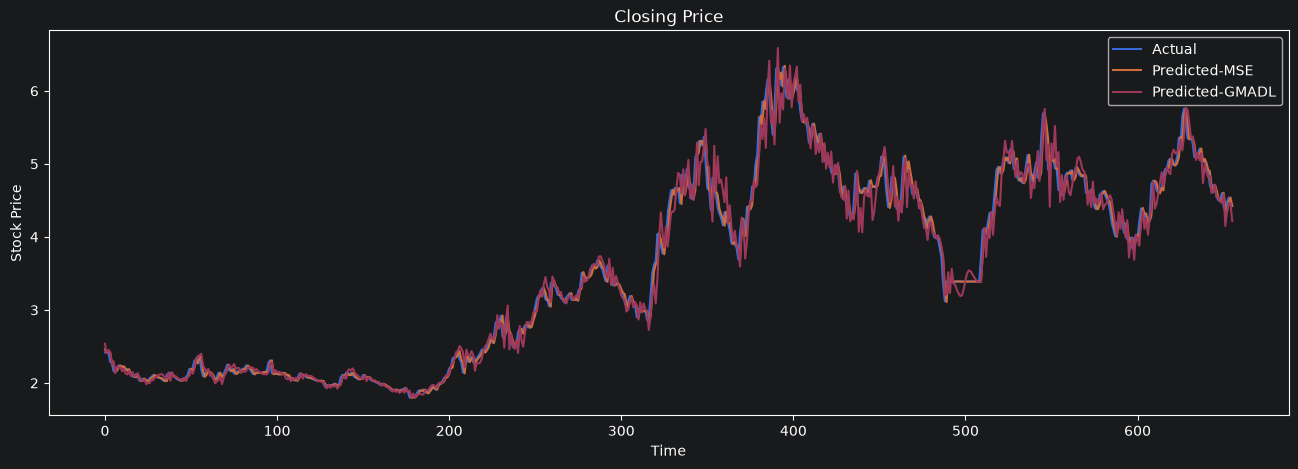

In [160]:
fig=plt.figure()
fig.set_figwidth(16)
fig.set_figheight(5)
plt.plot(actual, label='Actual')
plt.plot(predicted_close, label='Predicted-MSE')
plt.plot(predicted_close_GMADL, label='Predicted-GMADL')
plt.title('Closing Price')
plt.xlabel('Time')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

In [161]:
test_close = data["close"].iloc[val_end - look_back :].to_numpy()
actual_diff = np.diff(test_close)[look_back - 1 :]
hit_rate_MSE = np.mean(np.sign(actual_diff) == np.sign(predict_diff)) * 100
hit_rate_GMADL = np.mean(np.sign(actual_diff) == np.sign(predict_diff_GMADL)) * 100
mae_MSE = np.mean(np.abs(actual - predicted_close))
mae_GMADL = np.mean(np.abs(actual - predicted_close_GMADL))
print(f'hit rate MSE: {hit_rate_MSE} | hit rate GMADL: {hit_rate_GMADL}')
print(f'mean absolute error MSE: {mae_MSE} | mean absolute error GMADL: {mae_GMADL}')

hit rate MSE: 46.03658536585366 | hit rate GMADL: 45.426829268292686
mean absolute error MSE: 0.08464697392473267 | mean absolute error GMADL: 0.1278725874513555


**so essentially it's kinda ass because it predicts day to day change worse than random it just took previous-day data to minimize raw error lol** \
changing it to evaluating binary up/down changes would maybe work better \
zoomed in:

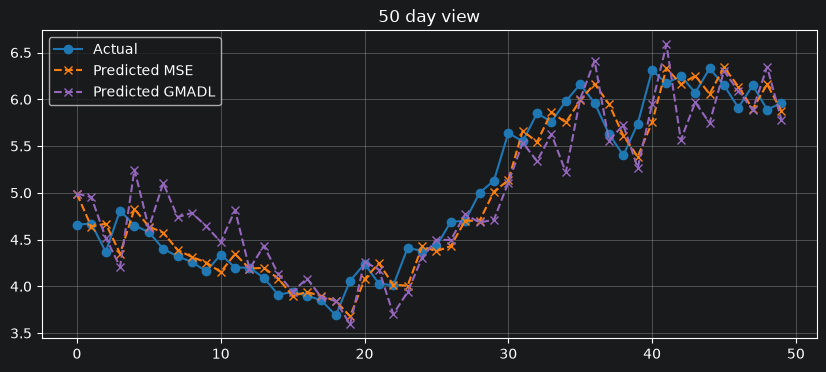

In [163]:
plt.figure(figsize=(10, 4))
plt.plot(
    actual[350:400], label="Actual", marker="o", color="tab:blue"
)
plt.plot(
    predicted_close[350:400],
    label="Predicted MSE",
    marker="x",
    color="tab:orange",
    linestyle="--",
)
plt.plot(
    predicted_close_GMADL[350:400],
    label="Predicted GMADL",
    marker="x",
    color="tab:purple",
    linestyle="--",
)
plt.title("50 day view")
plt.legend()
plt.grid(True)
plt.show()